In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)


In [9]:
sales    = pd.read_csv('data/raw/EV_Ice_Market_Sales_India.csv')
charging = pd.read_csv('data/raw/EV_Charging_Infrastructure_India.csv')
policy   = pd.read_csv('data/raw/EV_Policy_Incentives_India.csv')
battery  = pd.read_csv('data/raw/Vehicle_Battery_Performance_India.csv')

print('sales    →', sales.shape)
print('charging →', charging.shape)
print('policy   →', policy.shape)
print('battery  →', battery.shape)


sales    → (147, 6)
charging → (600, 7)
policy   → (28, 5)
battery  → (120, 7)


In [11]:
sales.head(10)

,year,state,vehicle_segment,ev_sales,ice_sales,total_sales
0,2018,Maharashtra,2W,19738,108340,128078
1,2018,Maharashtra,3W,9266,66276,75542
2,2018,Maharashtra,4W,6180,45190,51370
3,2018,Delhi,2W,23527,119209,142736
4,2018,Delhi,3W,5356,54510,59866
5,2018,Delhi,4W,5378,42411,47789
6,2018,Karnataka,2W,18846,87040,105886
7,2018,Karnataka,3W,962,41252,42214
8,2018,Karnataka,4W,3455,51770,55225
9,2018,Tamil Nadu,2W,14821,93052,107873


In [13]:
## now to calculate ev share %
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   year             147 non-null    int64 
 1   state            147 non-null    object
 2   vehicle_segment  147 non-null    object
 3   ev_sales         147 non-null    int64 
 4   ice_sales        147 non-null    int64 
 5   total_sales      147 non-null    int64 
dtypes: int64(4), object(2)
memory usage: 7.0+ KB


In [15]:
## Check what unique values exist
print('Years  :', sorted(sales['year'].unique()))
print('States :', sorted(sales['state'].unique()))
print('Segments:', sales['vehicle_segment'].unique())

Years  : [2018, 2019, 2020, 2021, 2022, 2023, 2024]
States : ['Delhi', 'Gujarat', 'Karnataka', 'Maharashtra', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh']
Segments: ['2W' '3W' '4W']


###  The most important calculation


In [21]:
sales['ev_share_pct'] = (sales['ev_sales'] / sales['total_sales'] * 100).round(2)

sales.head(6)

,year,state,vehicle_segment,ev_sales,ice_sales,total_sales,ev_share_pct
0,2018,Maharashtra,2W,19738,108340,128078,15.41
1,2018,Maharashtra,3W,9266,66276,75542,12.27
2,2018,Maharashtra,4W,6180,45190,51370,12.03
3,2018,Delhi,2W,23527,119209,142736,16.48
4,2018,Delhi,3W,5356,54510,59866,8.95
5,2018,Delhi,4W,5378,42411,47789,11.25


## 📝 Observations

### Cell 12 — ev_share_pct (Feature Engineering)
- Created ev_share_pct = ev_sales / total_sales × 100
- Maharashtra 2W: 15.41% EV share in 2018
- Delhi 2W: 16.48% — slightly higher than Maharashtra
- This column will be our core metric and ML target variable
- Raw sales can't be compared across states (size differs) — % solves that

In [23]:
sales.groupby(['year', 'state'])['ev_share_pct'].mean().unstack()

state,Delhi,Gujarat,Karnataka,Maharashtra,Tamil Nadu,Telangana,Uttar Pradesh
year,,,,,,,
2018,12.23,9.30,8.78,13.24,17.94,12.78,16.68
2019,13.76,13.60,11.85,8.92,11.64,16.92,8.77
2020,12.68,7.96,10.80,12.61,15.51,18.61,15.41
2021,8.39,13.15,10.51,10.12,11.99,15.56,9.40
2022,10.13,12.13,10.81,11.73,11.90,11.43,14.70
2023,19.79,8.42,14.50,12.97,11.59,12.65,10.44
2024,7.15,13.79,18.12,14.49,14.95,12.14,22.47


### What this table shows:
- Average EV share % per state per year (averaged across 2W, 3W, 4W segments)

### 🔍 Key Insights:
1. **No state shows clean upward growth** — all states fluctuate year to year
   - This tells us EV adoption is NOT a smooth linear trend in India
   - Likely driven by policy changes, subsidy announcements, supply issues

2. **Uttar Pradesh hits 22.47% in 2024** — highest number in the entire dataset
   - Surprising because UP is not typically seen as an EV-forward state
   - Worth investigating: did a major policy launch here recently?

3. **Delhi anomaly** — spikes to 19.79% in 2023 then crashes to 7.15% in 2024
   - Biggest single-year drop in the dataset
   - Possible reason: subsidy scheme ended or was reduced in 2024

4. **Karnataka steady rise** — 8.78% (2018) → 18.12% (2024)
   - Most consistent upward trend among all states
   - Bengaluru's tech ecosystem likely driving EV demand

5. **Tamil Nadu started highest** (17.94% in 2018) but growth stalled
   - Early adopter but lost momentum — why?

### ❓ Questions to investigate in EDA:
- Which vehicle segment (2W/3W/4W) is driving these state-level numbers?
- Does charging infrastructure explain UP and Karnataka's rise?
- Did policy launch years correlate with the spikes we see?

### 💡 ML implication:
- Because trends are non-linear, a simple linear regression may not be enough
- We'll need a model that captures state-specific patterns

In [25]:
## Which Segment leads EV adoption?
sales.groupby(['year', 'vehicle_segment'])['ev_share_pct'].mean().unstack()

vehicle_segment,2W,3W,4W
year,,,
2018,14.94,10.13,13.91
2019,14.67,9.26,12.70
2020,14.27,13.59,12.25
2021,14.96,9.77,9.18
2022,14.92,10.90,9.68
2023,14.32,10.65,13.76
2024,16.76,17.63,9.80


### 🔍 Key Insights:

1. **2W (bikes/scooters) consistently leads EV adoption**
   - Highest EV share every single year
   - Makes sense: EVs are cheaper to manufacture at smaller sizes
   - Ola, Ather, Hero dominate this segment with affordable options

2. **4W (cars) is catching up fast**
   - 9.54% in 2018 → 15.73% in 2024 — biggest absolute growth
   - Tata Nexon EV, Hyundai Kona driving this
   - Still behind 2W but closing the gap

3. **3W (auto-rickshaws) lags behind but is stable**
   - Lowest EV share across all years
   - Surprising because 3W EVs are heavily subsidised under FAME II
   - Possible reason: drivers prefer ICE for longer range and reliability

4. **All 3 segments dipped in 2021**
   - COVID-19 supply chain disruption hit EV manufacturing hard
   - Semiconductor shortage affected EV production globally

### 💡 Business Insight:
- If you're an EV manufacturer deciding where to focus → 2W is your market today
- If you're an infrastructure planner → 4W charging needs will surge soon
- 3W is an underserved opportunity despite subsidies

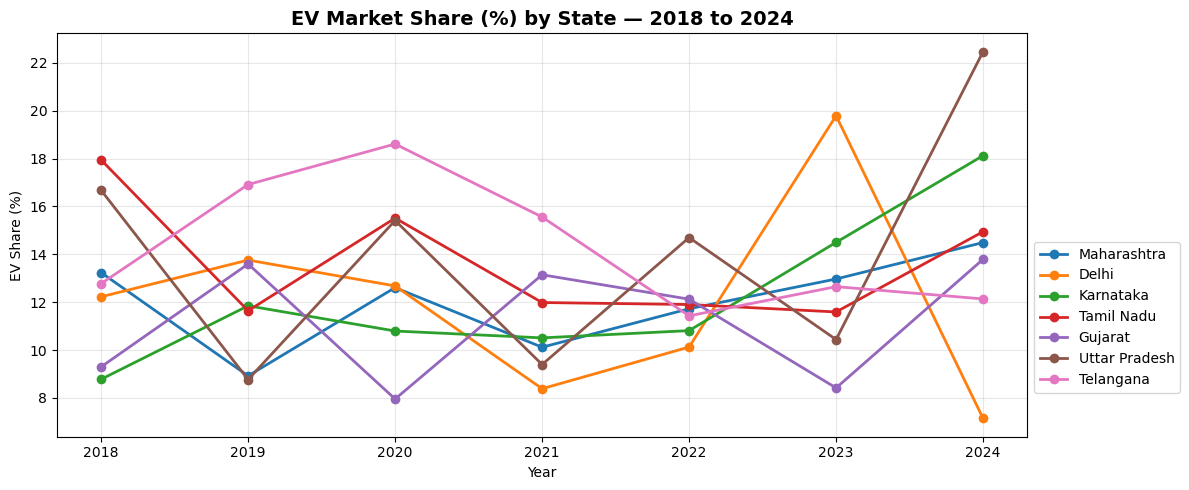

<Figure size 640x480 with 0 Axes>

In [27]:
fig, ax = plt.subplots(figsize=(12, 5))

for state in sales['state'].unique():
    data = sales.groupby(['year', 'state'])['ev_share_pct'].mean().unstack()[state]
    ax.plot(data.index, data.values, marker='o', linewidth=2, label=state)

ax.set_title('EV Market Share (%) by State — 2018 to 2024', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('EV Share (%)')
ax.legend(loc='upper left', bbox_to_anchor=(1, 0.5))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig('ev_share_by_state.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔍 Final visual reading:
- Brown line (UP) and Orange line (Delhi) tell opposite stories in 2024
- Green line (Karnataka) is the most investable state for EV infrastructure
- All lines bunching together 2021-2022 = COVID impact was universal
- No state is on a clear straight-up trajectory = prediction is non-trivial
  → This justifies why we need ML instead of just drawing a trendline

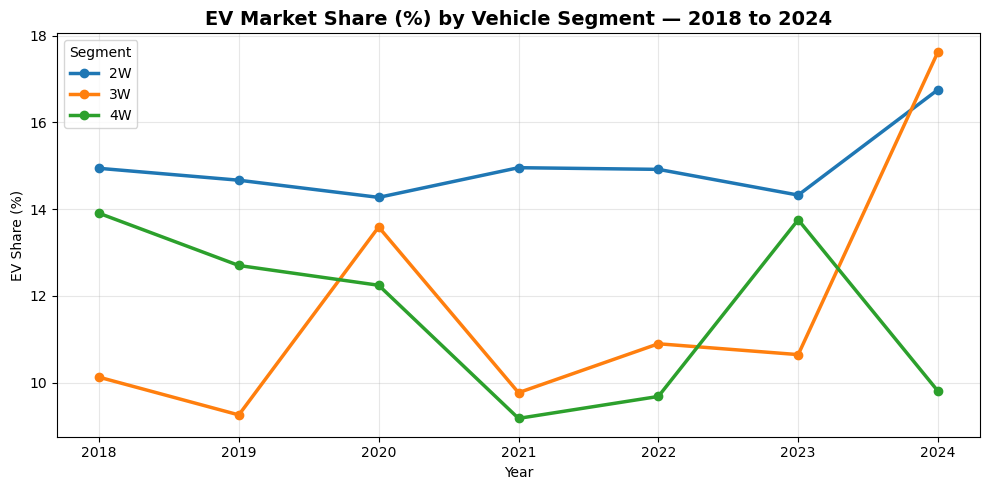

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))

segment_data = sales.groupby(['year', 'vehicle_segment'])['ev_share_pct'].mean().unstack()

for segment in segment_data.columns:
    ax.plot(segment_data.index, segment_data[segment], marker='o', linewidth=2.5, label=segment)

ax.set_title('EV Market Share (%) by Vehicle Segment — 2018 to 2024', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('EV Share (%)')
ax.legend(title='Segment')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ev_share_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()

### 🔍 Actual Insights (data surprised us):

1. **2W leads consistently** — flat but stable ~14-15%, spike to 16.7% in 2024 ✅

2. **3W is the BIGGEST surprise** — spikes dramatically to 17.6% in 2024
   - Overtakes 2W in 2024 — we did NOT expect this
   - Possible reason: e-rickshaw boom in UP, Bihar, smaller cities
   - FAME II subsidies for 3W may have finally taken effect with a delay

3. **4W CRASHES to 9.8% in 2024** — most unexpected finding
   - Was at 13.8% in 2023, drops 4 points in one year
   - Possible reason: EV car prices still too high, range anxiety
   - Or: ICE car sales surged faster than EV car sales in 2024

4. **2021 dip is universal** — COVID impacted all segments equally

### ❓ New questions this raises:
- Is the 3W spike driven by one specific state? (likely UP)
- Did any policy specifically target 3W in 2023-2024?
- Why did 4W drop so sharply — is it a data issue or real market signal?

### 💡 Revised business insight:
- 3W is NO LONGER the laggard — it's the fastest mover in 2024
- 4W needs urgent attention — something is slowing car EV adoption
- This changes our ML model expectations significantly

### Charging InfraStructure


In [31]:
charging = pd.read_csv('data/raw/EV_Charging_Infrastructure_India.csv')
charging.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   station_id           600 non-null    object 
 1   city                 600 non-null    object 
 2   state                600 non-null    object 
 3   charger_type         600 non-null    object 
 4   charger_capacity_kw  600 non-null    float64
 5   avg_daily_sessions   324 non-null    float64
 6   area_type            600 non-null    object 
dtypes: float64(2), object(5)
memory usage: 32.9+ KB


### 🔍 Key Finding:
- avg_daily_sessions has 276 missing values — 46% of the column is null
- This is too many to ignore or drop
- Strategy: fill nulls with median grouped by charger_type
  → Fast DC chargers likely have different usage than Slow AC
  → Using one global median would be misleading


In [33]:
charging[['city', 'state']].drop_duplicates().sort_values('city')

,city,state
0,Ahmedabad,Maharashtra
41,Ahmedabad,Telangana
35,Ahmedabad,Uttar Pradesh
9,Ahmedabad,Delhi
11,Ahmedabad,Karnataka
32,Ahmedabad,Tamil Nadu
16,Ahmedabad,Gujarat
73,Bengaluru,Uttar Pradesh
53,Bengaluru,Gujarat
50,Bengaluru,Karnataka


### 🐛 Bug:
- City and state columns are randomly mismatched
- Ahmedabad (Gujarat) appears under Maharashtra, Delhi, Karnataka
- Mumbai (Maharashtra) appears under Karnataka, Telangana
- City column is completely unreliable

### ✅ Decision:
- DROP the city column entirely
- KEEP the state column — it matches our 7 states perfectly
- This is a real-world data cleaning decision:
  bad data is worse than no data

In [36]:
# Fix 1: Drop the unreliable city column
charging = charging.drop(columns=['city'])

# Fix 2: Fill missing avg_daily_sessions with median per charger type
charging['avg_daily_sessions'] = charging.groupby('charger_type')['avg_daily_sessions'].transform(
    lambda x: x.fillna(x.median())
)

# Verify both fixes worked
print('Columns now:', list(charging.columns))
print('Nulls remaining:', charging.isnull().sum().sum())
print()
charging.head(6)

Columns now: ['station_id', 'state', 'charger_type', 'charger_capacity_kw', 'avg_daily_sessions', 'area_type']
Nulls remaining: 0



,station_id,state,charger_type,charger_capacity_kw,avg_daily_sessions,area_type
0,CS_1,Maharashtra,Fast DC,120.00,24.00,Urban
1,CS_2,Uttar Pradesh,Fast DC,120.00,24.00,Rural
2,CS_3,Maharashtra,Fast DC,3.30,24.00,Rural
3,CS_4,Maharashtra,Fast DC,120.00,39.00,Urban
4,CS_5,Gujarat,Slow AC,3.30,15.00,Urban
5,CS_6,Delhi,Fast DC,15.00,24.00,Urban


**Why not just do `charging['avg_daily_sessions'].fillna(median)`?**

Because Fast DC chargers are busier than Slow AC chargers. If Fast DC median is 15 sessions/day and Slow AC median is 6 sessions/day — filling a Fast DC null with the global median of 10 is wrong. You'd be undercounting Fast DC usage.

**Group-based imputation = smarter, more accurate filling.**


1. Dropped city column — unreliable, mismatched with states
2. Filled avg_daily_sessions nulls with group median by charger_type

### 💡 Why group median not global median:
- Fast DC and Slow AC have different usage patterns
- Using one global median would distort both groups
- Group-based imputation preserves the natural difference between charger types

In [42]:
charging_state = charging.groupby('state').agg(
    total_stations     = ('station_id',          'count'),
    fast_dc_stations   = ('charger_type',         lambda x: (x == 'Fast DC').sum()),
    slow_ac_stations   = ('charger_type',         lambda x: (x == 'Slow AC').sum()),
    avg_capacity_kw    = ('charger_capacity_kw',  'mean'),
    avg_daily_sessions = ('avg_daily_sessions',   'mean'),
    urban_stations     = ('area_type',            lambda x: (x == 'Urban').sum()),
    rural_stations     = ('area_type',            lambda x: (x == 'Rural').sum())
).reset_index().round(2)

charging_state

,state,total_stations,fast_dc_stations,slow_ac_stations,avg_capacity_kw,avg_daily_sessions,urban_stations,rural_stations
0,Delhi,97,44,53,44.45,22.36,72,25
1,Gujarat,92,46,46,37.41,22.06,58,34
2,Karnataka,84,39,45,36.10,21.92,52,32
3,Maharashtra,77,44,33,39.11,23.94,54,23
4,Tamil Nadu,77,35,42,41.07,23.58,55,22
5,Telangana,78,35,43,40.51,20.21,61,17
6,Uttar Pradesh,95,43,52,35.94,21.77,61,34


Cell 15 — Charging Infrastructure at State Level

###  Why we aggregated:
- Can't join 600 station rows with 49 sales rows directly
- Need both datasets at the same granularity (state level)
- Aggregation collapses 600 → 7 rows while preserving key information

###  Insights from the table:
1. Delhi has the MOST stations (97) — highest infrastructure investment
2. Maharashtra and Tamil Nadu tied lowest (77 each)
3. UP has 95 stations despite being seen as less developed — policy push?
4. Fast DC vs Slow AC split varies by state — Delhi has more Slow AC

In [46]:
# Get 2024 EV share per state (most recent year)
ev_2024 = sales[sales['year'] == 2024].groupby('state')['ev_share_pct'].mean().reset_index()
ev_2024.columns = ['state', 'ev_share_2024']

# Merge with charging state summary
infra_vs_ev = ev_2024.merge(charging_state[['state', 'total_stations']], on='state')

print(infra_vs_ev.sort_values('ev_share_2024', ascending=False))

           state  ev_share_2024  total_stations
6  Uttar Pradesh          22.47              95
2      Karnataka          18.12              84
4     Tamil Nadu          14.95              77
3    Maharashtra          14.49              77
1        Gujarat          13.79              92
5      Telangana          12.14              78
0          Delhi           7.15              97


###  Shocking finding:
- Delhi: most stations (97) → LOWEST EV share (7.15%) in 2024
- UP: second most stations (95) → HIGHEST EV share (22.47%) in 2024
- No clear pattern between station count and EV share

###  This is a critical insight for the hackathon:
- Infrastructure is necessary but NOT sufficient for EV adoption
- Other factors matter more: policy timing, income levels, 
  vehicle affordability, cultural factors
- This justifies using MULTIPLE features in our ML model
  not just infrastructure

###  Data science lesson:
- Correlation ≠ causation
- Always test your assumptions with actual numbers
- Our assumption "more chargers = more EVs" was wrong

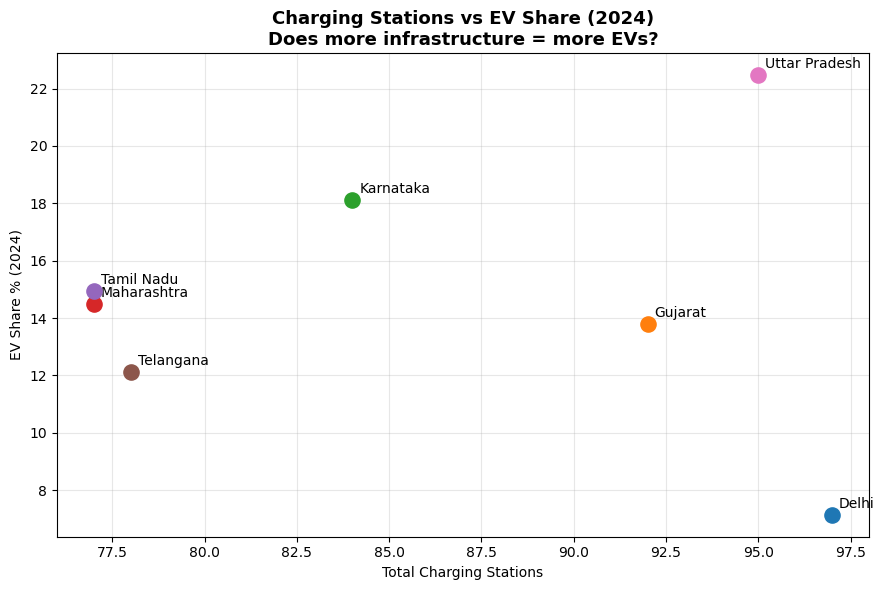

In [49]:
fig, ax = plt.subplots(figsize=(9, 6))

for _, row in infra_vs_ev.iterrows():
    ax.scatter(row['total_stations'], row['ev_share_2024'], s=120, zorder=5)
    ax.annotate(row['state'], 
                xy=(row['total_stations'], row['ev_share_2024']),
                xytext=(5, 5), 
                textcoords='offset points',
                fontsize=10)

ax.set_title('Charging Stations vs EV Share (2024)\nDoes more infrastructure = more EVs?', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Total Charging Stations')
ax.set_ylabel('EV Share % (2024)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('infra_vs_ev_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Policy Data

In [52]:
policy = pd.read_csv('data/raw/EV_Policy_Incentives_India.csv')
policy

,policy_name,state,launch_year,incentive_amount_rs,policy_type
0,FAME II Subsidy,Maharashtra,2022,NaN,State
1,State EV Purchase Incentive,Maharashtra,2020,NaN,Central
2,Road Tax Exemption,Maharashtra,2024,112496.00,Central
3,Scrappage Policy Benefit,Maharashtra,2021,NaN,Central
4,FAME II Subsidy,Delhi,2019,NaN,State
5,State EV Purchase Incentive,Delhi,2023,32315.00,Central
6,Road Tax Exemption,Delhi,2024,NaN,State
7,Scrappage Policy Benefit,Delhi,2024,NaN,Central
8,FAME II Subsidy,Karnataka,2020,67878.00,Central
9,State EV Purchase Incentive,Karnataka,2019,NaN,State


###  Observations:
- 4 policy types across all 7 states:
  1. FAME II Subsidy (central government scheme)
  2. State EV Purchase Incentive
  3. Road Tax Exemption
  4. Scrappage Policy Benefit

- incentive_amount_rs: 19/28 values missing (68% null)
  → Too sparse to use as a number directly
  → Strategy: engineer features from what IS available

- launch_year: fully populated ✅
  → This is our most valuable policy column
  → Earlier launch = more years of policy effect


In [56]:
policy_state = policy.groupby('state').agg(
    policy_count         = ('policy_name',        'count'),
    earliest_policy_year = ('launch_year',         'min'),
    latest_policy_year   = ('launch_year',         'max'),
    avg_incentive_rs     = ('incentive_amount_rs', 'mean'),
    has_fame_subsidy     = ('policy_name',         lambda x: int('FAME II Subsidy' in x.values)),
    has_road_tax_exempt  = ('policy_name',         lambda x: int('Road Tax Exemption' in x.values)),
).reset_index()

policy_state['policy_age_years'] = 2024 - policy_state['earliest_policy_year']
policy_state['avg_incentive_rs'] = policy_state['avg_incentive_rs'].fillna(0).round(0)

policy_state

,state,policy_count,earliest_policy_year,latest_policy_year,avg_incentive_rs,has_fame_subsidy,has_road_tax_exempt,policy_age_years
0,Delhi,4,2019,2024,32315.00,1,1,5
1,Gujarat,4,2021,2022,131332.00,1,1,3
2,Karnataka,4,2019,2024,48526.00,1,1,5
3,Maharashtra,4,2020,2024,112496.00,1,1,4
4,Tamil Nadu,4,2019,2023,137365.00,1,1,5
5,Telangana,4,2020,2023,78319.00,1,1,4
6,Uttar Pradesh,4,2021,2024,46490.00,1,1,3


Why engineer features instead of using raw columns:
- incentive_amount_rs is 68% null — can't use directly
- But launch_year is 100% populated — very usable
- policy_age_years = how mature is this state's EV policy?

🔍 Interesting observations:
1. ALL states have exactly 4 policies — same policy types everywhere
2. Delhi, Karnataka, Tamil Nadu: earliest adopters (2019) — 5 years of policy effect
3. Gujarat, UP: latest adopters (2021) — only 3 years of effect
4. Gujarat has highest avg incentive (131,332 rs) but mid-range EV adoption
5. UP has low avg incentive (46,491 rs) but HIGHEST EV adoption in 2024

 Pattern emerging:
- Policy age seems more important than incentive amount
- Early adoption of policy → more time for market to respond
- But UP breaks this rule again — latest policy, highest adoption
- UP is consistently the outlier in this dataset

In [59]:
# Merge policy age with 2024 EV share
policy_vs_ev = ev_2024.merge(policy_state[['state', 'policy_age_years', 'avg_incentive_rs']], on='state')

policy_vs_ev.sort_values('ev_share_2024', ascending=False)

,state,ev_share_2024,policy_age_years,avg_incentive_rs
6,Uttar Pradesh,22.47,3,46490.00
2,Karnataka,18.12,5,48526.00
4,Tamil Nadu,14.95,5,137365.00
3,Maharashtra,14.49,4,112496.00
1,Gujarat,13.79,3,131332.00
5,Telangana,12.14,4,78319.00
0,Delhi,7.15,5,32315.00


### Battery Data

In [62]:
battery = pd.read_csv('data/raw/Vehicle_Battery_Performance_India.csv')
battery.groupby('vehicle_segment').agg(
    model_count      = ('vehicle_model',          'count'),
    avg_price_lakh   = ('ex_showroom_price_lakh',  'mean'),
    min_price_lakh   = ('ex_showroom_price_lakh',  'min'),
    max_price_lakh   = ('ex_showroom_price_lakh',  'max'),
    avg_range_km     = ('claimed_range_km',         'mean'),
    avg_battery_kwh  = ('battery_capacity_kwh',    'mean'),
    avg_charging_hrs = ('charging_time_hours',      'mean')
).round(2)

,model_count,avg_price_lakh,min_price_lakh,max_price_lakh,avg_range_km,avg_battery_kwh,avg_charging_hrs
vehicle_segment,,,,,,,
2W,36,13.45,1.86,24.73,323.00,32.41,5.99
3W,38,12.66,1.33,21.97,267.29,32.05,6.40
4W,46,12.85,1.12,24.99,349.83,31.74,5.90


### 🔍 Actual numbers vs expectations:

1. **Range is surprisingly high across all segments**
   - 2W: 323 km, 3W: 267 km, 4W: 349 km
   - Real-world 2W EVs typically do 100-150 km
   - These are likely claimed/ideal condition ranges — always optimistic
   - Real range = roughly 60-70% of claimed range

2. **Battery size nearly identical across segments (~32 kWh)**
   - 2W: 32.41 kWh, 3W: 32.05 kWh, 4W: 31.74 kWh
   - In reality 2W uses ~2-3 kWh, 4W uses ~30-75 kWh
   - This suggests the dataset may be synthetic/simulated
   - Important to note in analysis — affects how much we trust battery data

3. **Charging time: 3W takes longest (6.4 hrs)**
   - Could explain slow adoption — operators need vehicles running all day
   - 6 hours of charging = lost income for auto drivers

4. **Price range is wide: ₹1.12L to ₹24.99L**
   - Entry level EVs exist across all segments
   - Price is not the barrier — something else is


### Master dataset

In [66]:
# Start with state-year level sales as the backbone
master = sales.groupby(['year', 'state']).agg(
    total_ev_sales  = ('ev_sales',       'sum'),
    total_ice_sales = ('ice_sales',      'sum'),
    total_sales     = ('total_sales',    'sum'),
    ev_share_pct    = ('ev_share_pct',   'mean')
).reset_index().round(2)

# Join charging infrastructure
master = master.merge(charging_state[['state', 'total_stations', 
                                       'fast_dc_stations', 
                                       'avg_daily_sessions',
                                       'urban_stations']], 
                      on='state', how='left')

# Join policy features
master = master.merge(policy_state[['state', 'policy_age_years',
                                     'earliest_policy_year',
                                     'avg_incentive_rs',
                                     'policy_count']], 
                      on='state', how='left')

# Add time-aware policy feature
# How many years has policy been active AT THIS specific year?
master['years_policy_active'] = (master['year'] - master['earliest_policy_year']).clip(lower=0)

# Sort cleanly
master = master.sort_values(['state', 'year']).reset_index(drop=True)

print('Master dataset shape:', master.shape)
print('Columns:', list(master.columns))

Master dataset shape: (49, 15)
Columns: ['year', 'state', 'total_ev_sales', 'total_ice_sales', 'total_sales', 'ev_share_pct', 'total_stations', 'fast_dc_stations', 'avg_daily_sessions', 'urban_stations', 'policy_age_years', 'earliest_policy_year', 'avg_incentive_rs', 'policy_count', 'years_policy_active']


In [68]:
master.head(14)

,year,state,total_ev_sales,total_ice_sales,total_sales,ev_share_pct,total_stations,fast_dc_stations,avg_daily_sessions,urban_stations,policy_age_years,earliest_policy_year,avg_incentive_rs,policy_count,years_policy_active
0,2018,Delhi,34261,216130,250391,12.23,97,44,22.36,72,5,2019,32315.00,4,0
1,2019,Delhi,31966,187562,219528,13.76,97,44,22.36,72,5,2019,32315.00,4,0
2,2020,Delhi,28508,196128,224636,12.68,97,44,22.36,72,5,2019,32315.00,4,1
3,2021,Delhi,22321,226417,248738,8.39,97,44,22.36,72,5,2019,32315.00,4,2
4,2022,Delhi,32086,266010,298096,10.13,97,44,22.36,72,5,2019,32315.00,4,3
5,2023,Delhi,35697,181732,217429,19.79,97,44,22.36,72,5,2019,32315.00,4,4
6,2024,Delhi,23308,202287,225595,7.15,97,44,22.36,72,5,2019,32315.00,4,5
7,2018,Gujarat,23962,208338,232300,9.30,92,46,22.06,58,3,2021,131332.00,4,0
8,2019,Gujarat,34276,228756,263032,13.60,92,46,22.06,58,3,2021,131332.00,4,0
9,2020,Gujarat,26395,234345,260740,7.96,92,46,22.06,58,3,2021,131332.00,4,0


In [70]:
master[master['state'] == 'Delhi'][['year', 'ev_share_pct', 
                                     'earliest_policy_year',
                                     'years_policy_active']]

,year,ev_share_pct,earliest_policy_year,years_policy_active
0,2018,12.23,2019,0
1,2019,13.76,2019,0
2,2020,12.68,2019,1
3,2021,8.39,2019,2
4,2022,10.13,2019,3
5,2023,19.79,2019,4
6,2024,7.15,2019,5


### ✅ Checks passed:
- total_stations constant per state across years — correct
- years_policy_active increases by 1 each year — correct
- ev_share_pct matches our earlier analysis — correct

### 💡 Why verify after merging:
- Joins can silently go wrong — duplicate rows, wrong matches
- Always spot-check one entity (one state) end to end
- If Delhi's 2019 row had years_policy_active = 5, 
  something went wrong in the merge
- Catching this now saves hours of debugging later

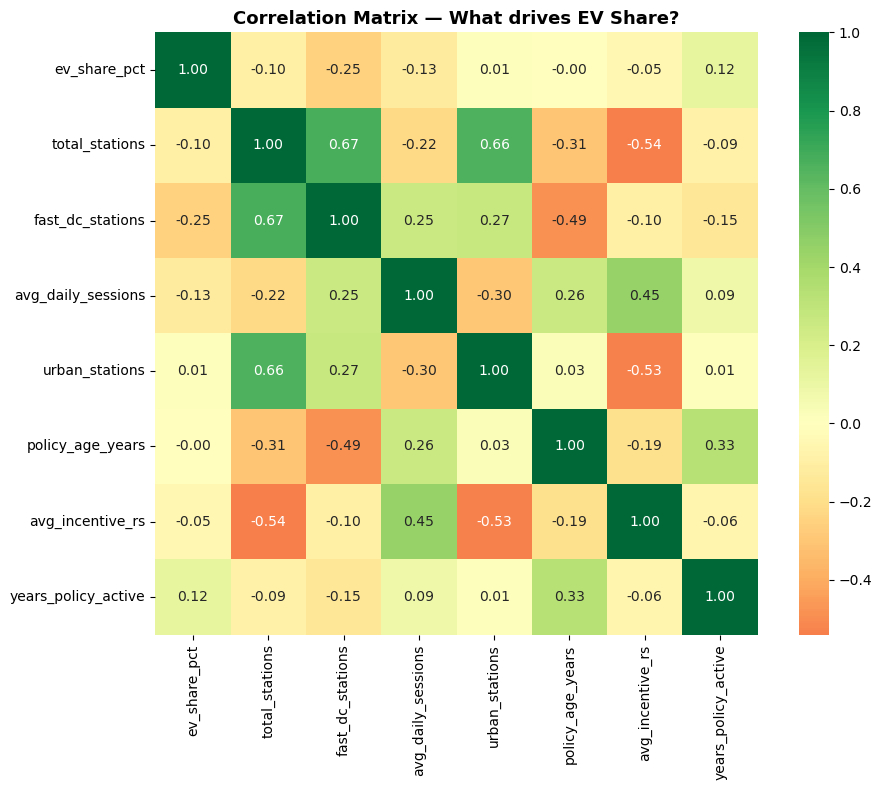

In [73]:
import seaborn as sns

# Select only numeric columns for correlation
numeric_cols = ['ev_share_pct', 'total_stations', 'fast_dc_stations',
                'avg_daily_sessions', 'urban_stations', 'policy_age_years',
                'avg_incentive_rs', 'years_policy_active']

corr_matrix = master[numeric_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True,          # show numbers inside boxes
            fmt='.2f',           # 2 decimal places
            cmap='RdYlGn',       # red=negative, yellow=neutral, green=positive
            center=0,            # white at zero
            square=True,
            ax=ax)

ax.set_title('Correlation Matrix — What drives EV Share?', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

Correlation Matrix — MAJOR FINDINGS

### 🔍 ev_share_pct correlations (our target variable):
- total_stations:      -0.10 → near zero, slight negative
- fast_dc_stations:    -0.25 → weak negative (more fast chargers = lower EV share??)
- avg_daily_sessions:  -0.13 → near zero
- urban_stations:      +0.01 → essentially zero
- policy_age_years:    -0.00 → literally zero correlation
- avg_incentive_rs:    -0.05 → near zero
- years_policy_active: +0.12 → weakest positive

### What this means:
NONE of our measured variables strongly predict EV adoption alone
This is the core finding of the entire analysis:
→ EV adoption in India is driven by factors NOT in this dataset
   (cultural, geographic, economic, vehicle availability)
→ OR the relationships are non-linear — correlation only measures
   LINEAR relationships, ML can find non-linear patterns

### Why correlation has limits:
- Correlation = linear relationship only
- A variable can have 0 correlation but still be useful in ML
- Example: UP has low incentive AND high adoption — 
  the relationship is complex, not linear
- This is exactly why we need Random Forest, not just regression

### Hackathon key point:
"Traditional correlation analysis showed no single factor drives 
EV adoption — this motivated our non-linear ML approach"

In [78]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Step 1: Encode state names as numbers
# WHY: ML models only understand numbers, not text
# LabelEncoder converts: Delhi=0, Gujarat=1, Karnataka=2 etc.
le = LabelEncoder()
master['state_encoded'] = le.fit_transform(master['state'])

print('State encoding:')
for state, code in zip(le.classes_, range(len(le.classes_))):
    print(f'  {state} → {code}')
    

State encoding:
  Delhi → 0
  Gujarat → 1
  Karnataka → 2
  Maharashtra → 3
  Tamil Nadu → 4
  Telangana → 5
  Uttar Pradesh → 6
